Verify that the data of your personal project have at least 2 continuous and 2 categorical or discrete variables. 
Otherwise change data.
With your data, proceed to the three analyses you did during the tutorial 1.

Understand data as actual values of random variables; Choose 2 variables of your project and make a probability model of them by assuming that each observation has been obtained by a simple random sampling (i.e. by drawing units uniformly with replacement in the population). Display a frequency table for your variables. Give explicitly the random variables involved and their expression in terms of your sample. What is the joint distribution of the frequencies displayed in the table ? 

The size of the sample, the number of classes and the notations must be clear. 
Proceed to a simple regression with 2 CONTINUOUS variables of your dataset. In this first part, you will write the model with all the assumptions (theoretical results must be written as a markdown), continue with the estimation of parameters, the regression line with all the necessary plots, CI for the prediction and the mean prediction. Outliers and residual analysis must be included. Make a decision about outliers (keep them or erase them from the set). 

Proceed to an analysis of variance with 1 DISCRETE or CATEGORICAL variable as input and 1 CONTINUOUS variables as output in your project.
Interpret and comment all your results.

In [214]:
import numpy as np
import scipy.stats as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [215]:
df = pd.read_csv('spotify.csv')
df

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [216]:
#sns.pairplot(df.sample(n=300))

In [217]:

corrcoef_table = df[["popularity","duration_ms","danceability","energy","loudness","speechiness","acousticness","liveness","valence","tempo"]].corr()

strong_corr = corrcoef_table.where((corrcoef_table > 0.6) | (corrcoef_table < -0.6))
strong_corr

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,liveness,valence,tempo
popularity,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_ms,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy,NaN,NaN,NaN,1.000000,0.76169,NaN,-0.733906,NaN,NaN,NaN
loudness,NaN,NaN,NaN,0.761690,1.00000,NaN,NaN,NaN,NaN,NaN
speechiness,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
acousticness,NaN,NaN,NaN,-0.733906,NaN,NaN,1.000000,NaN,NaN,NaN
liveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
valence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
tempo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


from this table , we can see that the only values that have a supposed correlation are :
energy/loudness & energy/acousticnesss –––––––––––– So we'll keep those 

### Data cleaning time, were only going to keep the track info and two categorical and three numerical variables 
here we decided to chose :
#### 3 numerical continuous variables
- **energy** : Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale

- **loudness** : The overall loudness of a track in decibels (dB)

- **acousticness** : A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic

#### 2 categorical variables
- **key** : The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1

- **track_genre** : The genre in which the track belongs


--- *source : kaggle description of the dataset* ---

### Making the dataset less big 
we have a little problem , if we try to find correlations right now we encounter 2 subproblems :
1. Because there is 114k rows the calculations are very costly
2. Because there are so much values if we plot anything we will not be able to see any correlation

SO we sample n = 1000

In [287]:
spotify = df[["artists","album_name","track_name","energy","loudness","acousticness","key","track_genre"]]
spotify = spotify.sample(n=500) 
spotify = spotify.reset_index()
spotify = spotify.drop("index",axis=1)
spotify

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
0,SadBoyProlific,Merlin,Merlin,0.346,-13.948,0.872000,8,sad
1,ZaZa,What I Do?,What I Do?,0.468,-15.257,0.115000,1,kids
2,Roger Miller,The Greatest Jazz Mix,King Of The Road - Single Version,0.366,-10.414,0.620000,11,country
3,Midnight Teds,Tonight We Gonna Raise the Flag,Heaven For a Ted,0.917,-3.764,0.156000,4,rockabilly
4,Greensky Bluegrass,Stress Dreams,Until I Sing,0.467,-12.365,0.588000,5,bluegrass
...,...,...,...,...,...,...,...,...
495,Lund,Skin & Bones,Skin & Bones,0.285,-11.580,0.822000,7,chill
496,Parkway Drive,Darker Still,Glitch,0.870,-3.998,0.000095,1,metalcore
497,Kyodi,Pleasure,Pleasure [Fuck Again],0.706,-4.761,0.611000,11,dancehall
498,Nathan Dawe;Jaykae;Malika,10's Dance Classics,Flowers,0.925,-4.518,0.015200,5,house


/Users/enzoducros/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


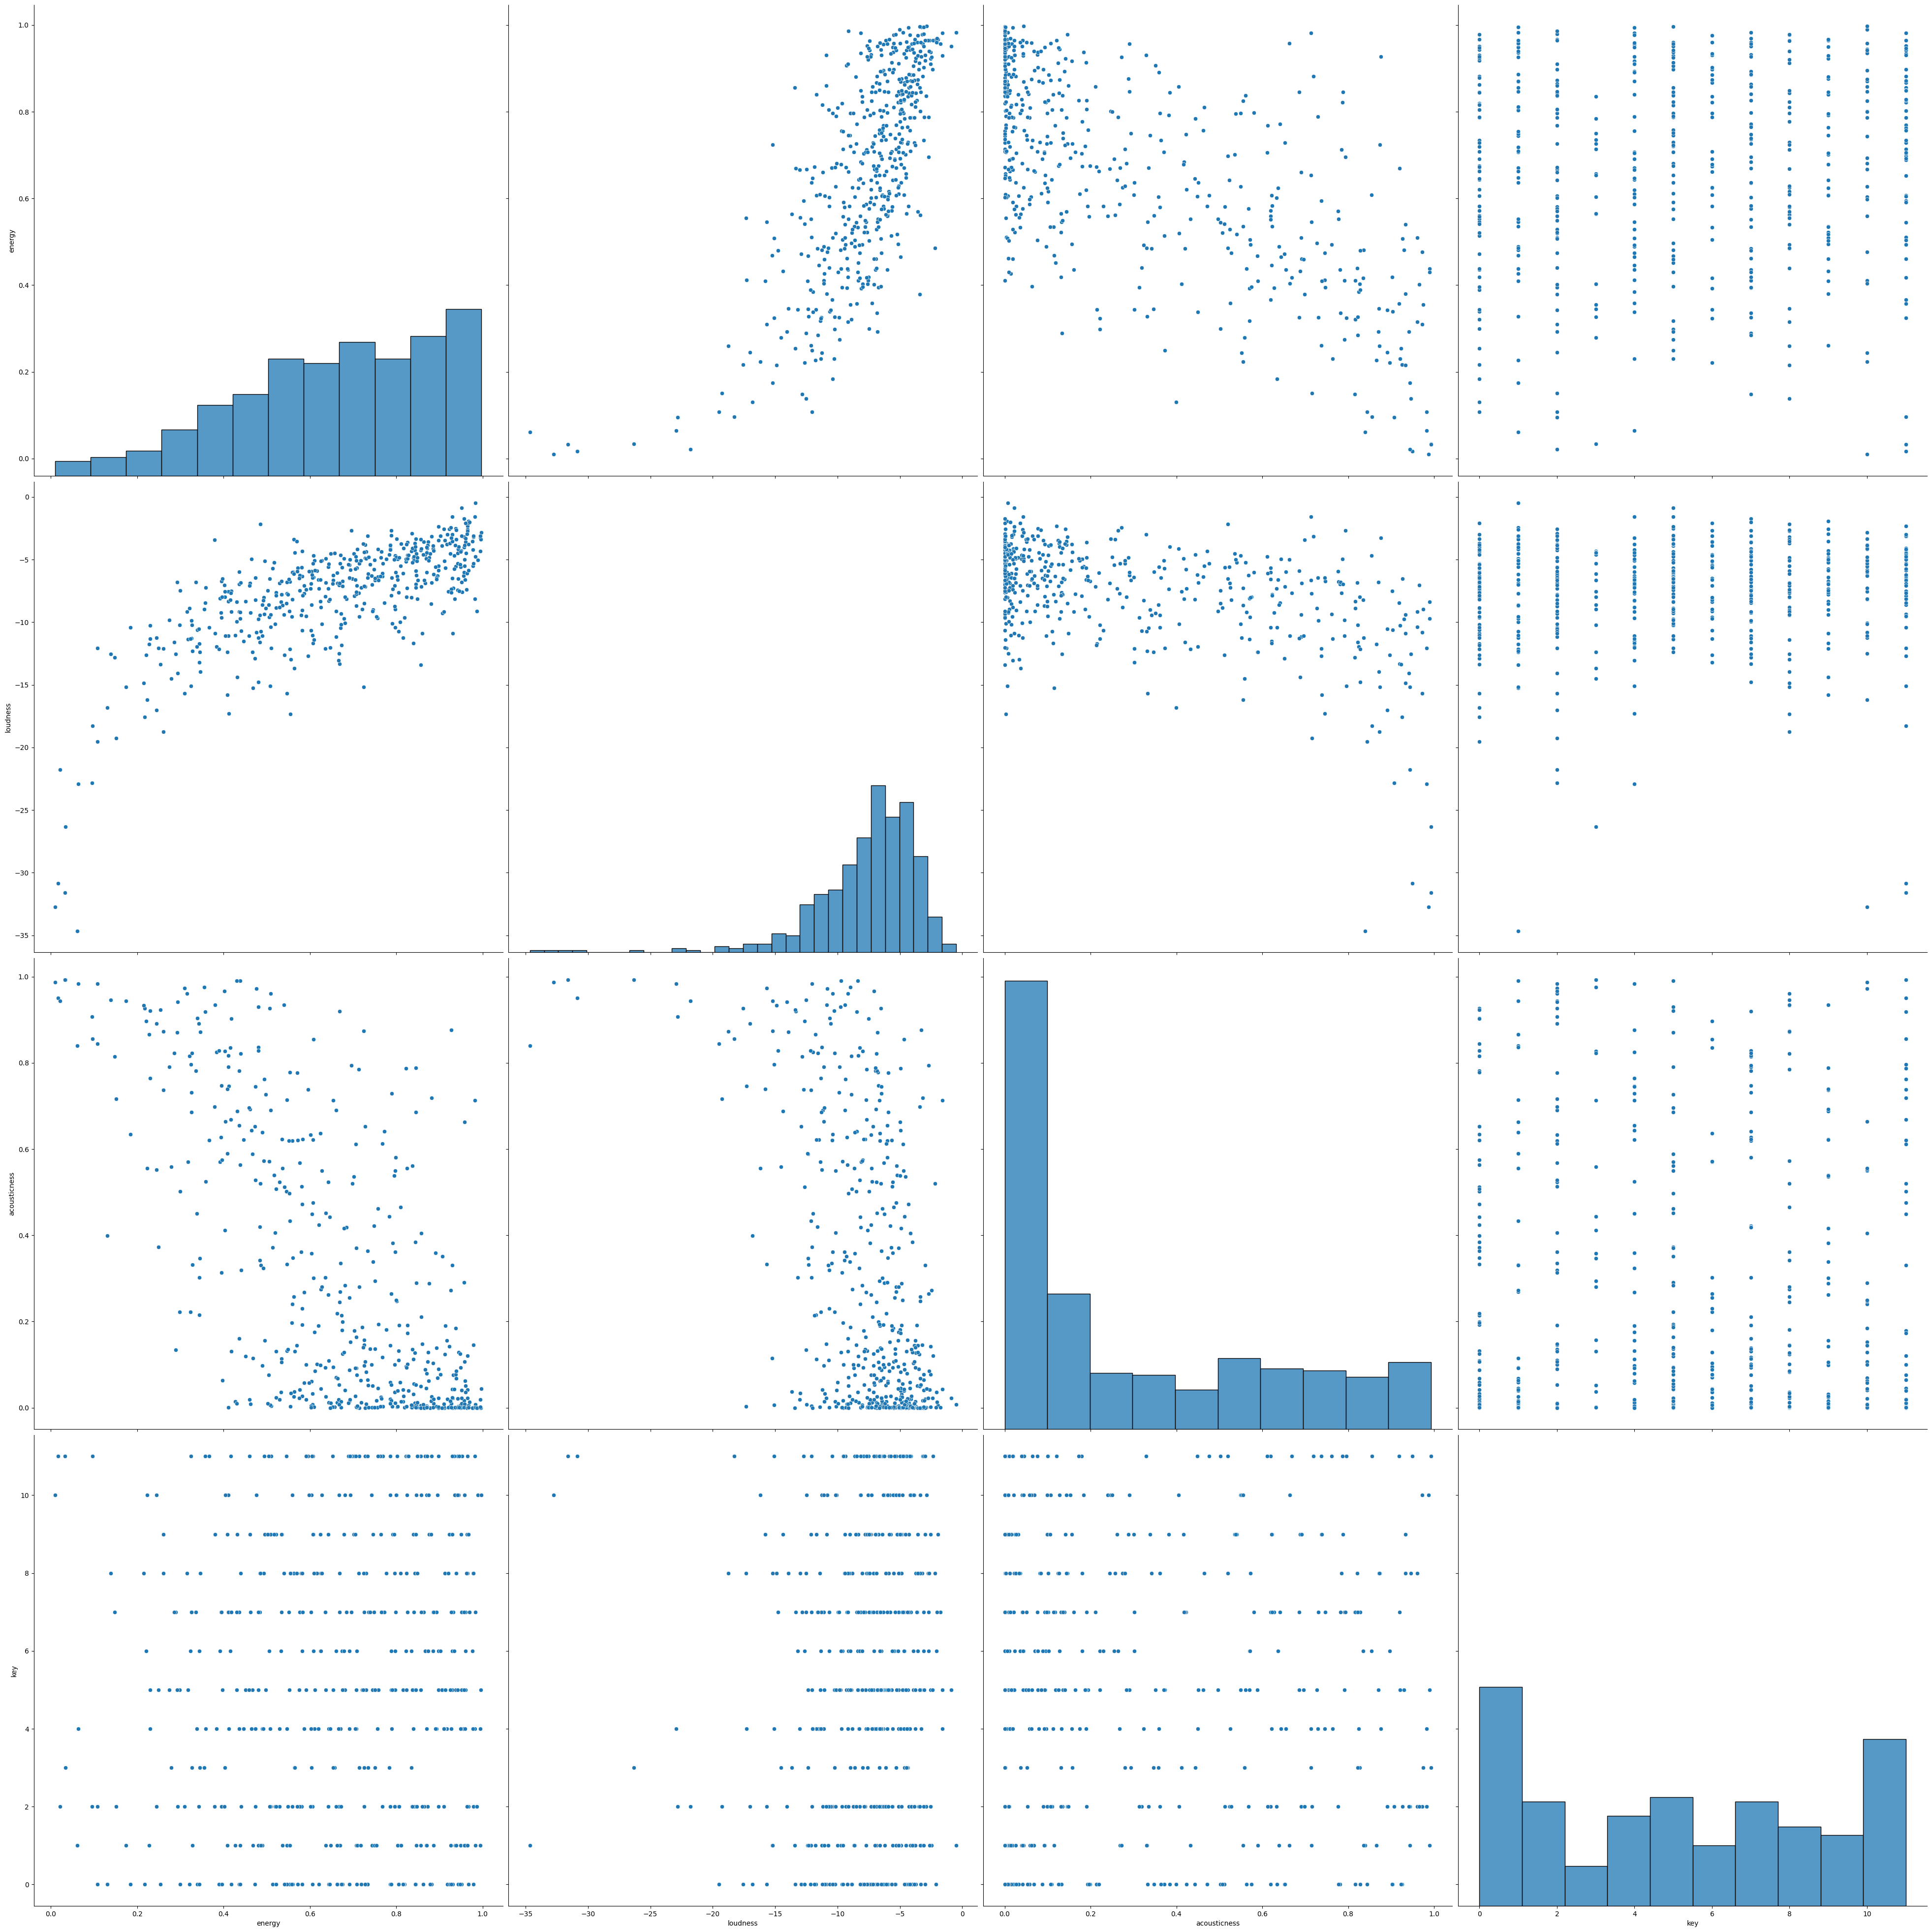

In [288]:
#fig , ax = plt.subplots(figsize =(10,7),dpi=100)
spotify.iloc[:,3:]
sns.pairplot(spotify.iloc[:,3:],size=10)

 We can observe an exponential relation in between loudness & energy, so if we linearise the model we might just find a lienar model 

# LINEAR REGRESSION - hell yeah
1. linearization
2. linear regression

<Axes: xlabel='loudness', ylabel='energy'>

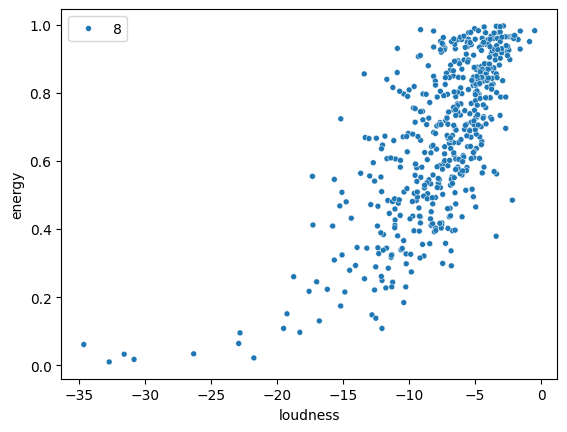

In [289]:
spotify_lr = spotify[["loudness","energy"]] # first we only take the two 
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size=8)

In [290]:
np.corrcoef(x=spotify_lr.loudness,y=spotify_lr.energy)

array([[1.        , 0.71860899],
       [0.71860899, 1.        ]])

# LINEARIZATION ( we tried but it didn't work)

**1. Linearisation**

In [291]:
# to linearise , we'll apply a map to the y value
spotify_linearized = pd.DataFrame()
spotify_linearized['loudness'] = spotify_lr["loudness"]
spotify_linearized["energy"] = spotify_lr["energy"].map(np.log)
spotify_linearized


,loudness,energy
0,-13.948,-1.061317
1,-15.257,-0.759287
2,-10.414,-1.005122
3,-3.764,-0.086648
4,-12.365,-0.761426
...,...,...
495,-11.580,-1.255266
496,-3.998,-0.139262
497,-4.761,-0.348140
498,-4.518,-0.077962


In [292]:
# removing the outlier 
spotify_linearized = spotify_linearized.where(spotify_linearized > -10)
spotify_linearized = spotify_linearized.dropna()
spotify_linearized

,loudness,energy
3,-3.764,-0.086648
5,-5.783,-0.290352
6,-6.951,-0.830113
7,-4.491,-0.420071
8,-6.530,-0.359536
...,...,...
492,-6.514,-0.923819
494,-3.741,-0.324346
496,-3.998,-0.139262
497,-4.761,-0.348140


array([[1.        , 0.55396983],
       [0.55396983, 1.        ]])

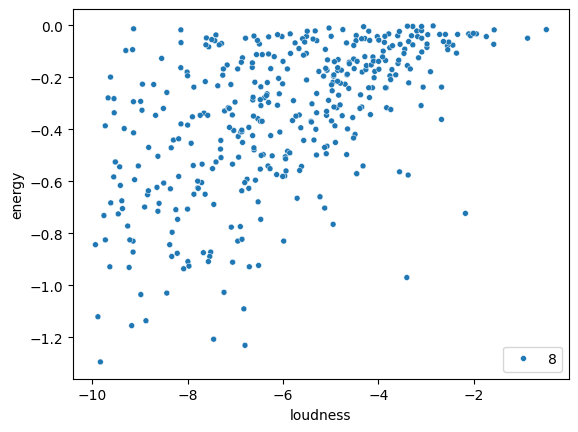

In [293]:
sns.scatterplot(data=spotify_linearized,x='loudness',y='energy',size = 8)
np.corrcoef(spotify_linearized.energy,spotify_linearized.loudness)
# hey , the corr coefficient is 0.8 , it's good 


# CONTINUE HERE

**2. Start of Linear Regression**

In [330]:
lr = st.linregress(x=spotify_lr.loudness,y=spotify_lr.energy)
a = lr.intercept
b = lr.slope
coef = [b,a]
boundaries = [-30,0]

hy=a+b*spotify_lr.loudness
e= spotify_lr.energy-hy
sse= np.sum(e**2)
hs2=sse/(n-2)
lr


LinregressResult(slope=np.float64(0.0384760477369567), intercept=np.float64(0.9570079796145585), rvalue=np.float64(0.7186089921672988), pvalue=np.float64(1.3587559169333784e-80), stderr=np.float64(0.001668502199590899), intercept_stderr=np.float64(0.014669863073673893))

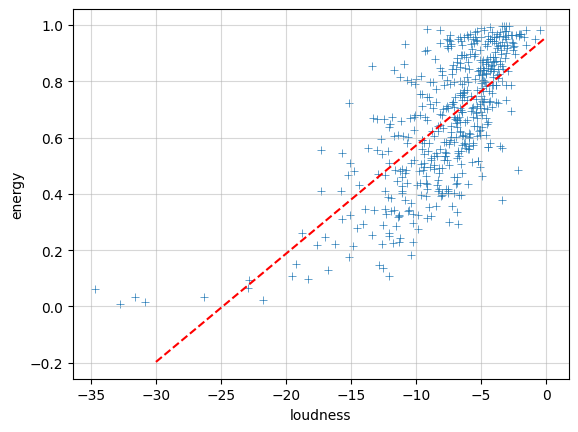

In [295]:
# lets plot this 
line = np.poly1d(coef)
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',marker="+")
plt.plot(boundaries,line(boundaries),'r--')
plt.grid(alpha = 0.5)


## outliers ? 

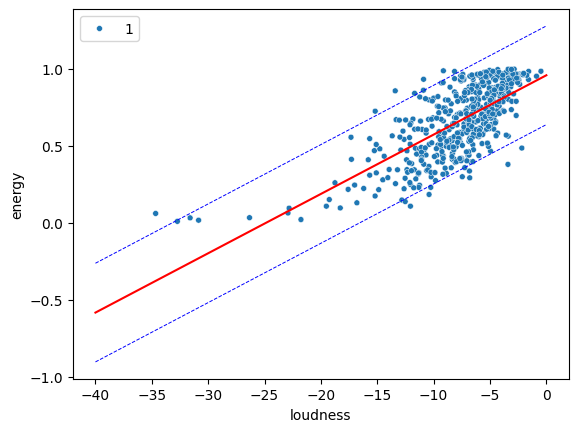

In [321]:
z = [-40,0]
sns.scatterplot(data=spotify_lr , x="loudness" , y="energy" ,size=1)


plt.plot(z,line(z),'r-')
plt.plot(z,line(z)+ 2*np.sqrt(hs2),'b--',linewidth = 0.7)
plt.plot(z,line(z)- 2*np.sqrt(hs2),'b--',linewidth = 0.7)

we remove the outliers and retry the linear regression

In [333]:
band = 2 * np.sqrt(hs2)

lower = hy - band
upper = hy + band

spotify_lr_clean = spotify_lr.where(
    (spotify_lr["energy"] >= lower) & (spotify_lr["energy"] <= upper)
)

spotify_lr_clean = spotify_lr_clean.dropna()

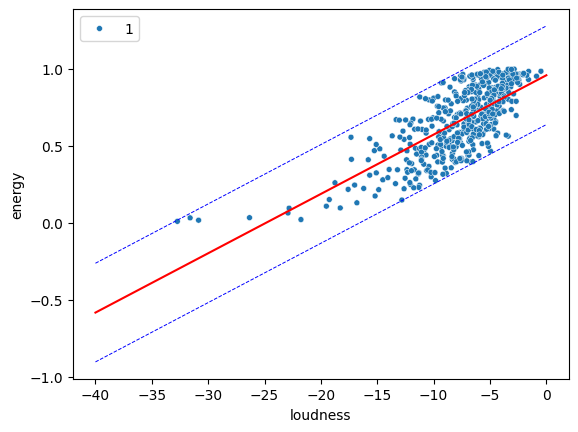

In [334]:
z = [-40,0]
sns.scatterplot(data=spotify_lr_clean , x="loudness" , y="energy" ,size=1)


plt.plot(z,line(z),'r-')
plt.plot(z,line(z)+ 2*np.sqrt(hs2),'b--',linewidth = 0.7)
plt.plot(z,line(z)- 2*np.sqrt(hs2),'b--',linewidth = 0.7)

Now we redo the regresison

In [337]:
lr = st.linregress(x=spotify_lr_clean.loudness,y=spotify_lr_clean.energy)
a = lr.intercept
b = lr.slope
coef = [b,a]
boundaries = [-30,0]

hy=a+b*spotify_lr_clean.loudness
e= spotify_lr.energy-hy
sse= np.sum(e**2)
hs2=sse/(n-2)
lr

LinregressResult(slope=np.float64(0.041006906946173496), intercept=np.float64(0.9776921155997734), rvalue=np.float64(0.7588883139922958), pvalue=np.float64(1.8613155485707033e-91), stderr=np.float64(0.001606152546067743), intercept_stderr=np.float64(0.01383898913767129))

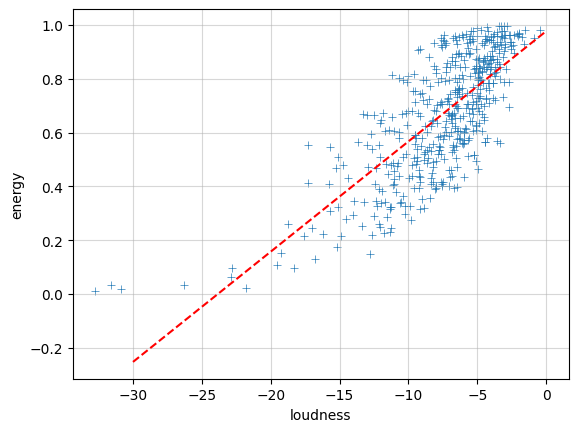

In [338]:
line = np.poly1d(coef)
sns.scatterplot(data=spotify_lr_clean,x='loudness',y='energy',marker="+")
plt.plot(boundaries,line(boundaries),'r--')
plt.grid(alpha = 0.5)

<Axes: xlabel='loudness', ylabel='energy'>

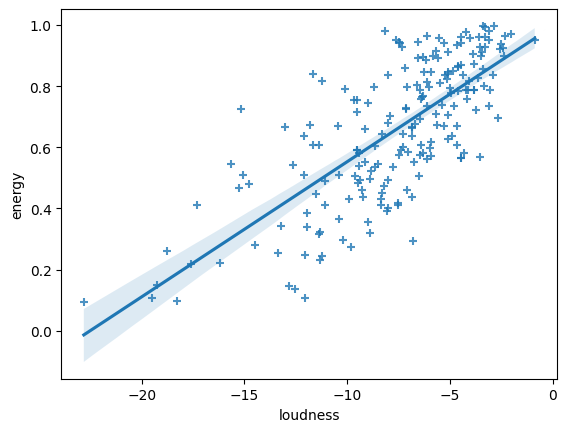

In [339]:
sns.regplot(data=spotify.sample(200),x='loudness',y='energy',marker='+')

### continum analysis

In [340]:
x = spotify_lr_clean.loudness
y = spotify_lr_clean.energy
n = len(spotify_lr_clean.loudness)

hy = a+b*x
e = y - hy

sse = np.sum(e**2)
hs2 = sse/(n-2)

residual analysis

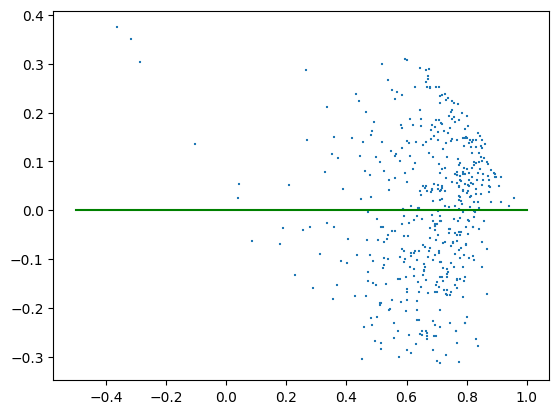

In [341]:
plt.scatter(x=hy,y=e,marker="+",s= 4)
plt.plot([-0.5,1],[0,0],'g')

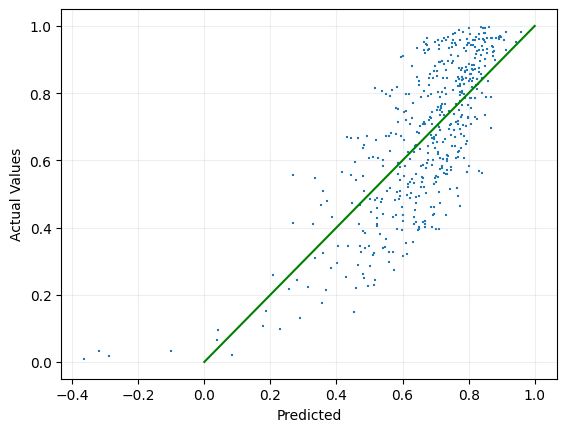

In [342]:
plt.scatter(x=hy,y=y,marker="+",s=7-5)
plt.plot([0,1],[0,1],'g')
plt.xlabel('Predicted')
plt.ylabel('Actual Values')
plt.grid(visible=True,alpha=0.2)

### q-q plot

In [343]:
dist = st.norm(loc=0,scale=np.sqrt(hs2))
dist

Text(0.5, 1.0, 'q-q plot')

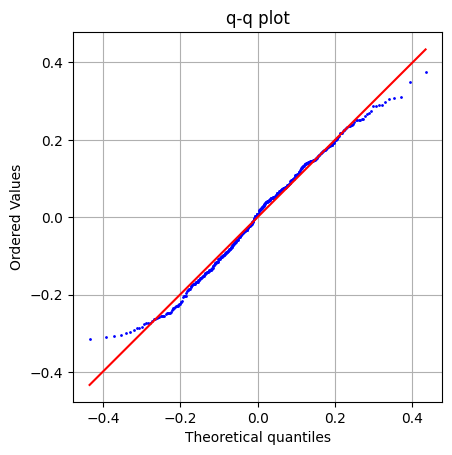

In [344]:

st.probplot(e,dist=dist,plot=plt)
plt.gca().lines[0].set_markersize(1)
plt.axis('square')
plt.grid()
plt.title("q-q plot")

**INterpratation** : the q-q plot is fine , however the residuals express heteroscadisticity , maybe they just have different sigmas. So technically we cannot apply our linear regression

# Anova regression

Proceed to an analysis of variance with 1 DISCRETE or CATEGORICAL variable as input and 1 CONTINUOUS variables as output in your project.
Interpret and comment all your results.

We take the categorical variable of the genre , and the continuous one being the energy 
We also chose 9 genres to make the analysis simpler 

In [303]:
# Only choosing some categories
types_list = ['house','r-n-b','jazz','brazil','emo','acoustic','latino','drum-and-bass','opera']
spotify_Anova = spotify[spotify['track_genre'].isin(types_list)]
spotify_Anova

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
11,RADWIMPS;Toko Miura,Weathering With You,Celebration (Movie Edit) [feat. Toko Miura],0.9230,-2.554,0.142000,9,emo
13,O Rappa,O Rappa - Acústico Oficina Francisco Brennand ...,Monstro invisível - Ao vivo,0.9580,-5.510,0.107000,10,brazil
28,Congo Natty;Rebel MC;Tenor Fly;Top Cat;General...,Aries & Kelvin 373 present Born On Road x Jung...,UK Allstars - Congo Natty Meets Benny Page Rem...,0.9320,-7.291,0.076200,7,drum-and-bass
33,Calvin Harris;Tom Grennan,By Your Side (feat. Tom Grennan),By Your Side (feat. Tom Grennan),0.9600,-3.597,0.051400,7,house
34,ilyTOMMY,Princess Bubblegum,Princess Bubblegum,0.4840,-11.613,0.420000,7,emo
73,Tiësto;Charli XCX,New Arrivals,Hot in It,0.8410,-5.080,0.004450,7,house
101,The Weepies;Deb Talan;Steve Tannen,Hideaway,Can't Go Back Now,0.5520,-9.114,0.497000,5,acoustic
109,Kiara Vitória,Despreocupa,Despreocupa,0.5810,-5.614,0.513000,2,brazil
120,Kid Abelha,Meio Desligado (Acústico),Por que não eu? - Acústico,0.4460,-11.506,0.622000,4,r-n-b
176,Tiësto;Charli XCX,Hit After Hit,Hot in It,0.8410,-5.080,0.004450,7,house


In [304]:
spotify_Anova = spotify_Anova[['track_genre','energy']]
spotify_Anova

,track_genre,energy
11,emo,0.9230
13,brazil,0.9580
28,drum-and-bass,0.9320
33,house,0.9600
34,emo,0.4840
73,house,0.8410
101,acoustic,0.5520
109,brazil,0.5810
120,r-n-b,0.4460
176,house,0.8410


<Axes: xlabel='track_genre', ylabel='energy'>

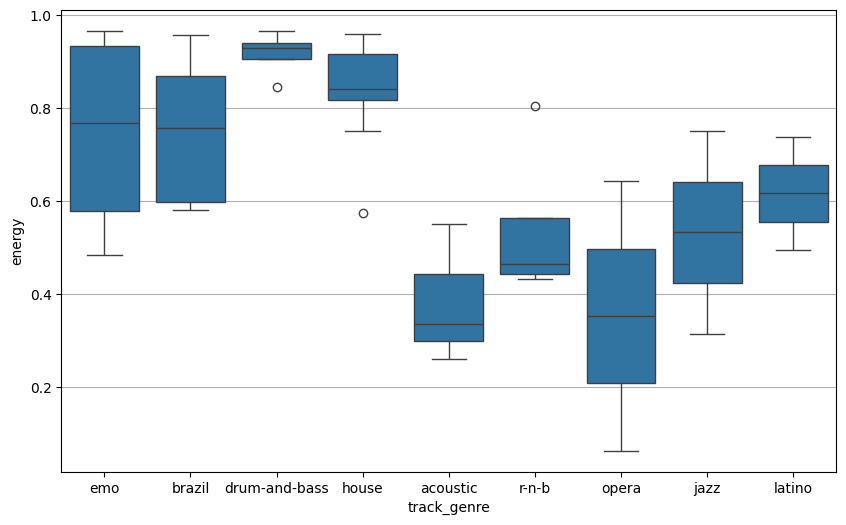

In [312]:
# BOxplottts 
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid()
sns.boxplot(data=spotify_Anova, x="track_genre", y="energy", ax=ax)


Hey , there seems to be a good difference in between types  , and also some that maybe are very similar ( for example drum&Bass and house that are very similar in style so it's not suprising that they have similar boxplots )

## analysis of variance

In [306]:
spotify_Anova.groupby('track_genre').describe()

energy                                                        \
               count      mean       std     min      25%     50%      75%   
track_genre                                                                  
acoustic         3.0  0.383000  0.151086  0.2610  0.29850  0.3360  0.44400   
brazil           7.0  0.747429  0.157004  0.5810  0.59900  0.7580  0.86850   
drum-and-bass    4.0  0.917500  0.051604  0.8450  0.90575  0.9290  0.94075   
emo              4.0  0.746500  0.235775  0.4840  0.58000  0.7675  0.93400   
house            8.0  0.830875  0.122336  0.5750  0.81825  0.8410  0.91675   
jazz             2.0  0.533000  0.308299  0.3150  0.42400  0.5330  0.64200   
latino           2.0  0.617000  0.172534  0.4950  0.55600  0.6170  0.67800   
opera            2.0  0.353400  0.409556  0.0638  0.20860  0.3534  0.49820   
r-n-b            4.0  0.542000  0.176762  0.4320  0.44250  0.4655  0.56500   

                      
                 max  
track_genre           
acoustic       0.552  
brazil         0.958  
drum-and-bass  0.967  
emo            0.967  
house          0.960  
jazz           0.751  
latino         0.739  
opera          0.643  
r-n-b          0.805

#### with an scipy stats function

In [307]:
groups = [g["energy"].to_numpy()for _, g in spotify_Anova.groupby("track_genre")]

anova = st.f_oneway(groups[0],groups[1],groups[2],groups[3],groups[4],groups[5],groups[6],groups[7],groups[8])
print(f"the d statistic is {anova.statistic} with p-value {anova.pvalue}")
print(f" the statistic is very high and p-value is very low so we can conclude that the track genre does impact energy , we reject H_O")

the d statistic is 4.157291544186152 with p-value 0.002421599863783562
 the statistic is very high and p-value is very low so we can conclude that the track genre does impact energy , we reject H_O


# FULL ANOVA REGRESSION

In [308]:
y = [list(g["energy"])  for _, g in spotify_Anova.groupby("track_genre")]
y = pd.DataFrame(y)
y = y.T
y

,0,1,2,3,4,5,6,7,8
0,0.552,0.958,0.932,0.923,0.960,0.315,0.495,0.0638,0.446
1,0.261,0.581,0.926,0.484,0.841,0.751,0.739,0.6430,0.432
2,0.336,0.607,0.967,0.612,0.841,NaN,NaN,NaN,0.805
3,NaN,0.591,0.845,0.967,0.750,NaN,NaN,NaN,0.485
4,NaN,0.758,NaN,NaN,0.841,NaN,NaN,NaN,NaN
5,NaN,0.835,NaN,NaN,0.575,NaN,NaN,NaN,NaN
6,NaN,0.902,NaN,NaN,0.914,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,0.925,NaN,NaN,NaN,NaN


In [309]:
def fisher_exo2(df):
    k = df.shape[1]
    ni = df.notna().sum()
    n = np.sum(ni)
    yib = df.mean()
    yb = df.mean(axis = None) # tells pandas that the summation is not in respect to the same axis
    ssm = np.sum(ni*(yib-yb)**2)
    sse = ((df-yib)**2).mean(axis=None)*n
    f = (ssm/(k-1))/(sse/(n-k))
    p = st.f.sf(k,k-1,n-k)
    return k,ni,yib,yb,ssm,sse,f,p



In [310]:
k,ni,yib,yb,ssm,sse,f,p = fisher_exo2(y)

print(yib)
print(p)

0    0.383000
1    0.747429
2    0.917500
3    0.746500
4    0.830875
5    0.533000
6    0.617000
7    0.353400
8    0.542000
dtype: float64
6.2009278079915545e-06


We do not reject because p-value<0.05


We cannot reject that the track genre has an impact on the energy of the song 